In [1]:
import os
import librosa
import librosa.display
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
import seaborn as sns
import glob
from tqdm import tqdm
import pickle
import IPython.display as ipd  # To play sound in the notebook
import soundfile as sf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [2]:
# --- 1. Konfigurasi dan Konstanta ---
DATASET_PATH = "dataset" # Pastikan folder 'dataset' berada di direktori yang sama dengan skrip ini
COMMANDS = ["baca", "berhenti", "foto", "halo", "info", "kembali", "ulang"]

SAMPLE_RATE = 16000
N_MFCC = 13
N_MELS = 22
WINDOW = int(SAMPLE_RATE * 0.01) # 10 ms window
HOP = int(WINDOW / 2) # 50% overlap


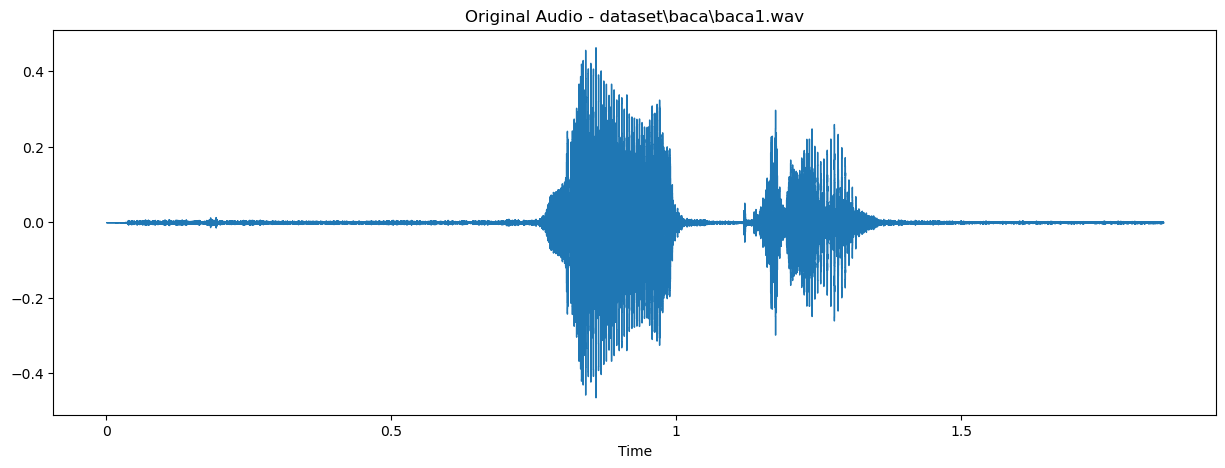

In [3]:
#Audio Original

sample_command = "baca"
sample_file = os.path.join(DATASET_PATH, sample_command, os.listdir(os.path.join(DATASET_PATH, sample_command))[0])
data, sampling_rate = librosa.load(sample_file, sr=None)

# Tampilkan waveform dan play audio
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)
plt.title(f"Original Audio - {sample_file}")
plt.show()

# Play audio
ipd.Audio(data, rate=sampling_rate)

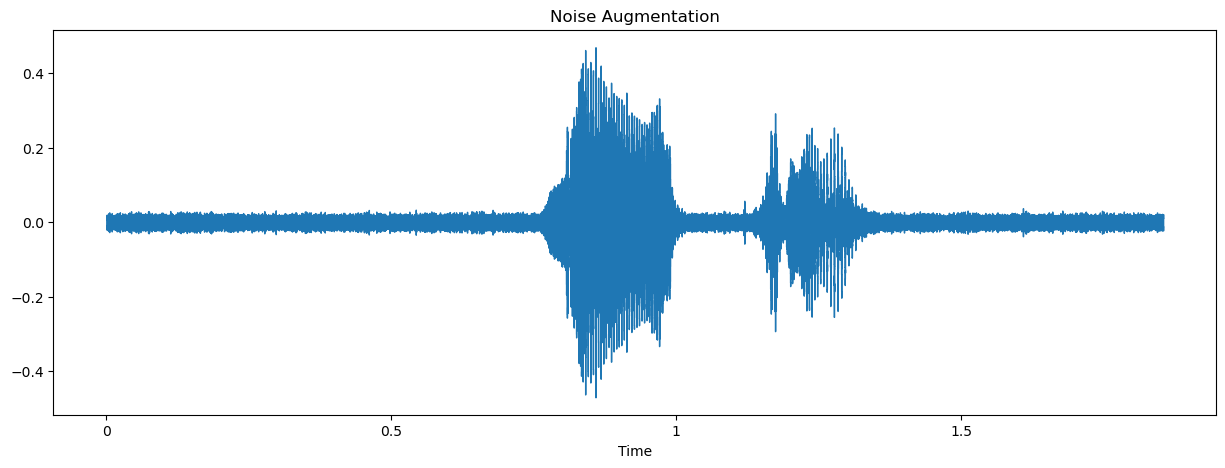

In [4]:
def noise(data):
    noise_amp = 0.05 * np.random.uniform() * np.amax(data)
    data = data.astype('float64') + noise_amp * np.random.normal(size=data.shape[0])
    return data

# Apply
x = noise(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Noise Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)

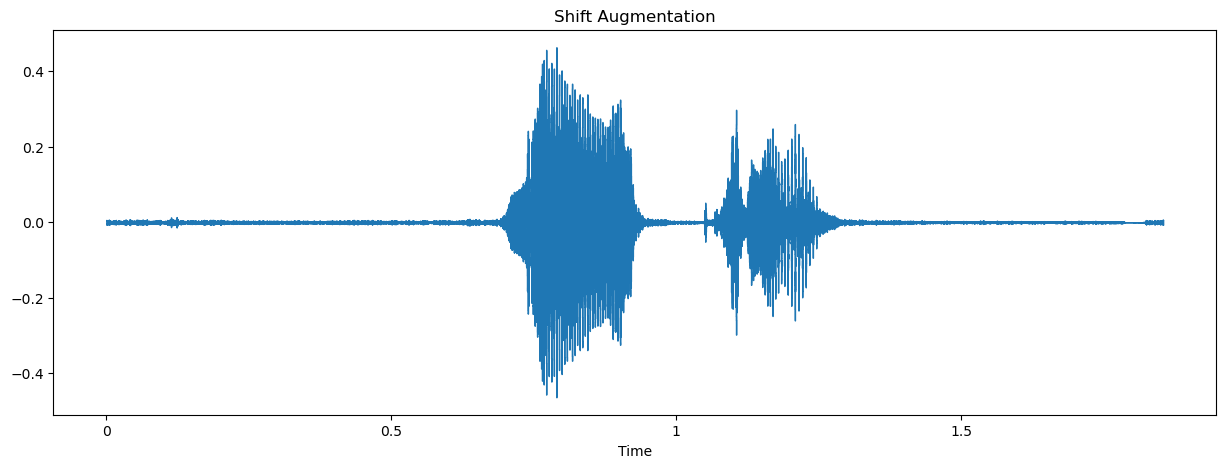

In [5]:
# def shift(data):
#     s_range = int(np.random.uniform(low=-5, high=5) * 1000)
#     return np.roll(data, s_range)

def shift(data, shift_fraction=0.05):
    max_shift = int(len(data) * shift_fraction)
    shift_amt = np.random.randint(-max_shift, max_shift)
    return np.roll(data, shift_amt)

x = shift(data, shift_fraction=0.05)

plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Shift Augmentation")
plt.show()

ipd.Audio(x, rate=sampling_rate)


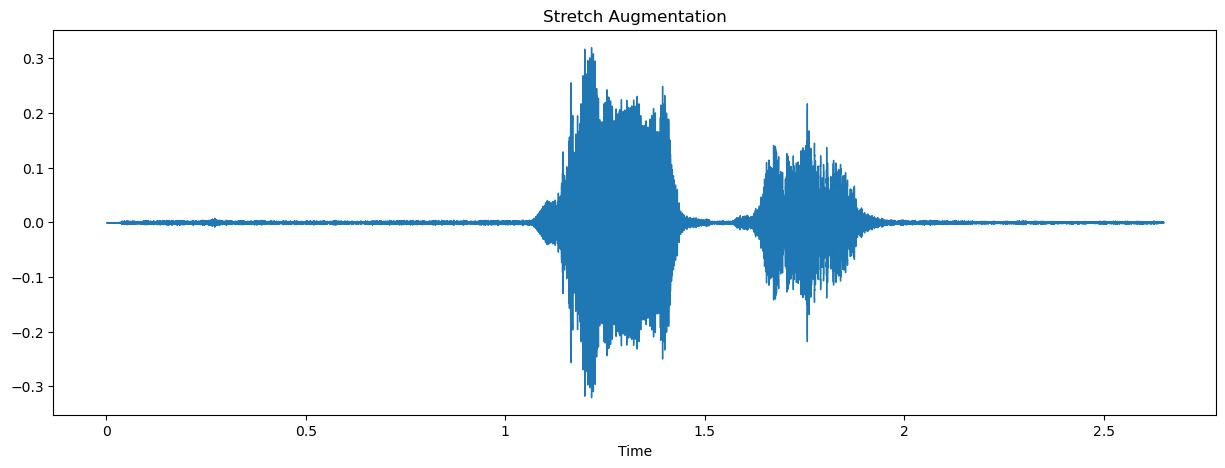

In [6]:
def stretch(data, rate=0.7):
    return librosa.effects.time_stretch(data, rate=rate)

x = stretch(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Stretch Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)

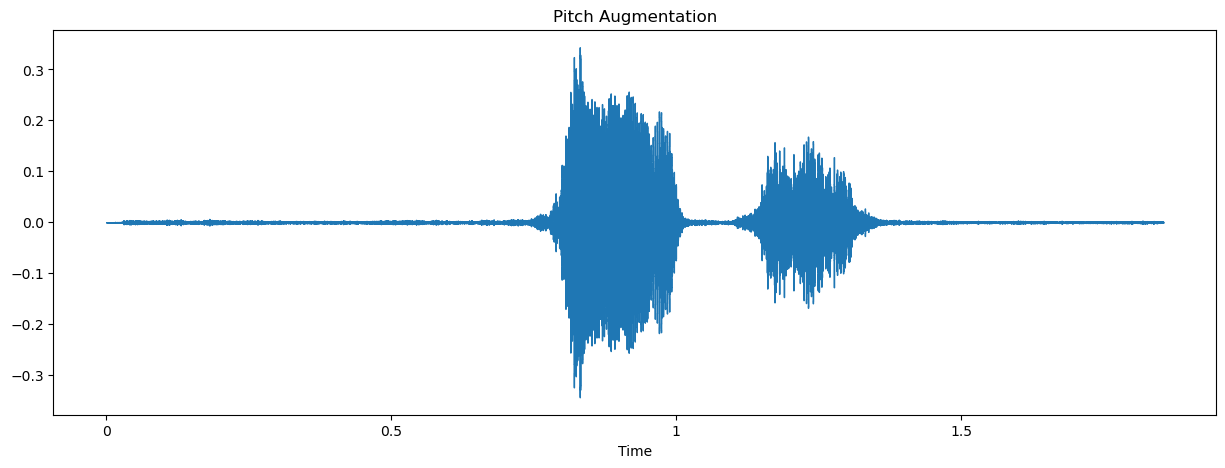

In [7]:
def pitch(data, sample_rate):
    bins_per_octave = 12
    pitch_pm = 2
    pitch_change = pitch_pm * 2 
    data = librosa.effects.pitch_shift(y=data.astype('float64'), 
                                       sr=sample_rate, 
                                       n_steps=pitch_change, 
                                       bins_per_octave=bins_per_octave)
    return data


x = pitch(data, sampling_rate)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Pitch Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)


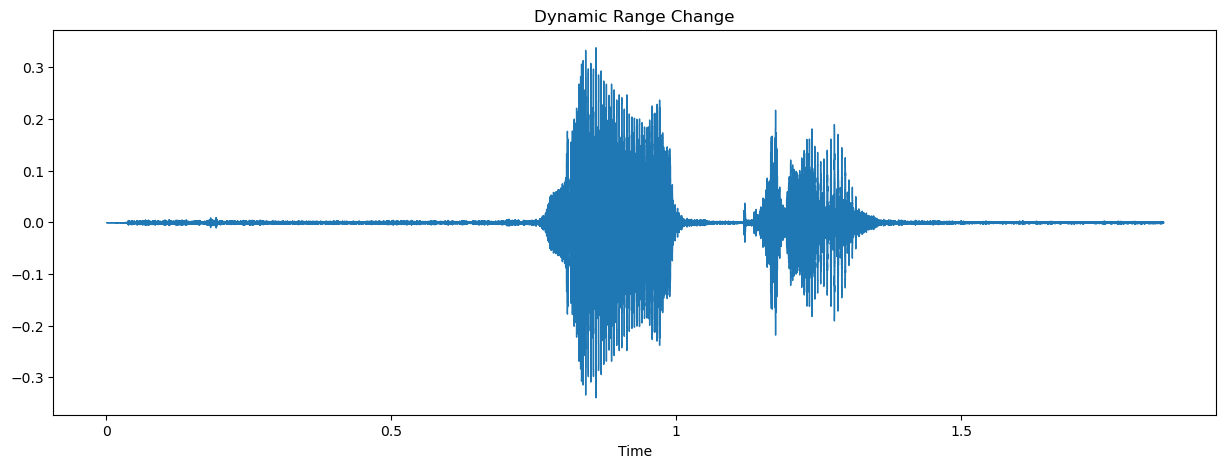

In [8]:
def dyn_change(data):
    dyn = np.random.uniform(low=0.3, high=2.0)
    return data * dyn

x = dyn_change(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Dynamic Range Change")
plt.show()
ipd.Audio(x, rate=sampling_rate)


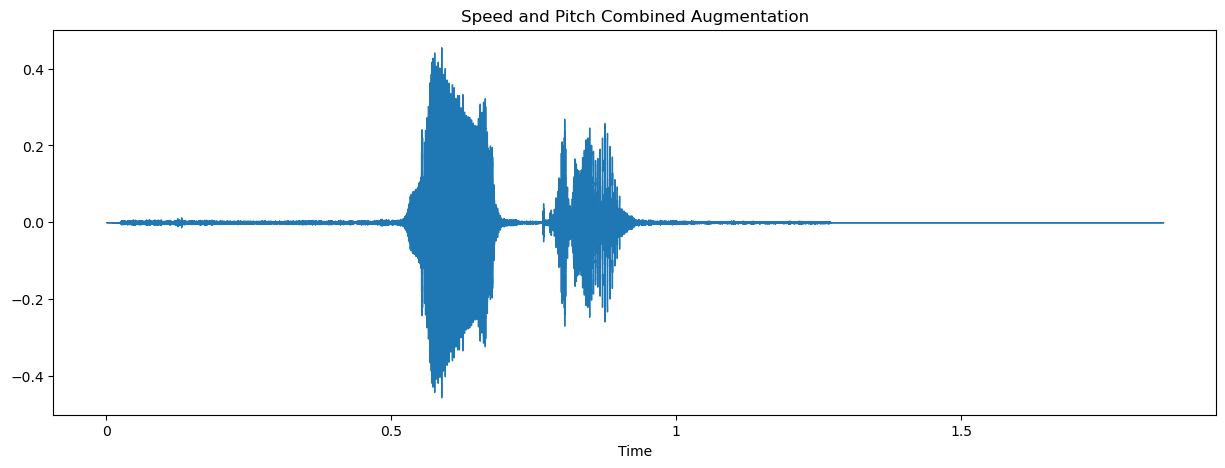

In [9]:
def speedNpitch(data):
    length_change = np.random.uniform(low=0.8, high=1)
    speed_fac = 1.2 / length_change
    tmp = np.interp(np.arange(0, len(data), speed_fac), np.arange(0, len(data)), data)
    minlen = min(len(data), len(tmp))
    data = np.zeros_like(data)
    data[0:minlen] = tmp[0:minlen]
    return data

x = speedNpitch(data)
plt.figure(figsize=(15, 5))
librosa.display.waveshow(x, sr=sampling_rate)
plt.title("Speed and Pitch Combined Augmentation")
plt.show()
ipd.Audio(x, rate=sampling_rate)


In [10]:
# --- 3. Fungsi Ekstraksi MFCC ---
def extract_mfcc(signal):
    """
    Mengekstrak MFCC dari sinyal audio.
    signal: numpy array dari sinyal audio.
    """
    return librosa.feature.mfcc(
        y=signal,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS,
        n_fft=WINDOW,
        hop_length=HOP
    ).T

In [11]:
# --- 4. Fungsi Encoding dan Padding ---
def encode_and_pad(df_train, df_valid):
    """
    Melakukan encoding label dan padding MFCC untuk mempersiapkan data input model.
    df_train: DataFrame training.
    df_valid: DataFrame validation.
    """
    le = LabelEncoder()
    df_train['label_encoded'] = le.fit_transform(df_train['label'])
    df_valid['label_encoded'] = le.transform(df_valid['label'])

    # Menentukan panjang maksimum MFCC untuk padding
    all_mfcc = df_train['mfcc'].tolist() + df_valid['mfcc'].tolist()
    max_len = max(len(x) for x in all_mfcc)
    print(f"Panjang MFCC maksimum untuk padding: {max_len}")

    # Padding sequence MFCC
    X_train = pad_sequences(df_train['mfcc'], maxlen=max_len, padding='post', dtype='float32')
    X_valid = pad_sequences(df_valid['mfcc'], maxlen=max_len, padding='post', dtype='float32')

    # One-hot encoding untuk label
    y_train = to_categorical(df_train['label_encoded'])
    y_valid = to_categorical(df_valid['label_encoded'])

    return X_train, y_train, X_valid, y_valid, le

In [12]:
# --- 5. Loading Data Awal ---
print("Memuat data audio...")
all_data = []
for command in COMMANDS:
    command_path = os.path.join(DATASET_PATH, command)
    if not os.path.exists(command_path):
        print(f"Direktori '{command_path}' tidak ditemukan. Pastikan dataset sudah diunduh dan diatur dengan benar.")
        continue # Lewati jika direktori tidak ada

    for filename in os.listdir(command_path):
        if filename.endswith(".wav"):
            filepath = os.path.join(command_path, filename)
            try:
                # Memuat sinyal dengan sample rate yang konsisten
                signal, sr = librosa.load(filepath, sr=SAMPLE_RATE)
                all_data.append({
                    'filepath': filepath,
                    'label': command,
                    'signal': signal,
                    'sr': sr
                })
            except Exception as e:
                print(f"Error loading {filepath}: {e}")

if not all_data:
    print("Tidak ada data audio yang berhasil dimuat. Pastikan jalur dataset dan file .wav sudah benar.")
    exit() # Keluar jika tidak ada data

df = pd.DataFrame(all_data)
print(f"Total {len(df)} file audio dimuat.")

Memuat data audio...
Total 3217 file audio dimuat.



--- Tampilan Sinyal Asli, Mel Spectrogram, dan Sinyal Teraugmentasi per Label ---

--- Label: BACA ---


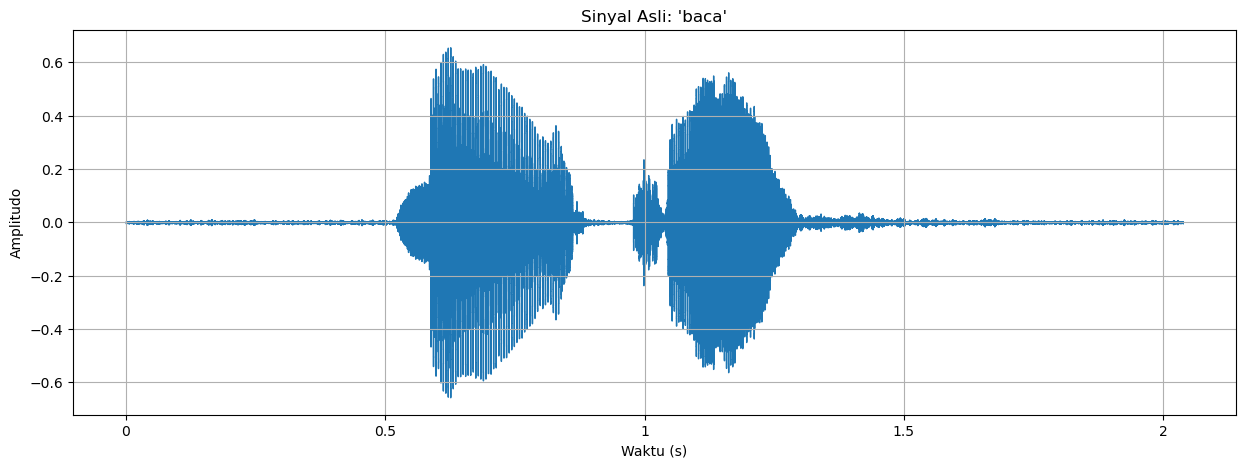

Sinyal Asli:


AttributeError: No librosa attribute power_to_to_db

<Figure size 1500x500 with 0 Axes>

In [15]:
# --- 6. Tampilan Sinyal, Mel Spectrogram, dan Sinyal Teraugmentasi per Label ---
print("\n--- Tampilan Sinyal Asli, Mel Spectrogram, dan Sinyal Teraugmentasi per Label ---")
for label in COMMANDS:
    print(f"\n--- Label: {label.upper()} ---")

    # Ambil satu contoh file untuk label ini
    label_df = df[df['label'] == label].sample(1) # Ambil 1 contoh acak
    if not label_df.empty:
        sample = label_df.iloc[0]
        signal = sample['signal']
        sr = sample['sr']

        # Sinyal Asli
        plt.figure(figsize=(15, 5))
        librosa.display.waveshow(signal, sr=sr)
        plt.title(f"Sinyal Asli: '{label}'")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Amplitudo")
        plt.grid(True)
        plt.show()
        print("Sinyal Asli:")
        ipd.display(ipd.Audio(signal, rate=sr))

        # Mel Spectrogram
        plt.figure(figsize=(15, 5))
        mel_spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr, n_fft=WINDOW, hop_length=HOP, n_mels=N_MELS)
        mel_spectrogram_db = librosa.power_to_to_db(mel_spectrogram, ref=np.max) # Menggunakan power_to_db
        librosa.display.specshow(mel_spectrogram_db, sr=sr, x_axis='time', y_axis='mel')
        plt.colorbar(format='%+2.0f dB')
        plt.title(f"Mel Spectrogram: '{label}'")
        plt.tight_layout()
        plt.show()

        # Sinyal Teraugmentasi
        augmented_signal = speedNpitch(signal, sr)
        plt.figure(figsize=(15, 5))
        librosa.display.waveshow(augmented_signal, sr=sr)
        plt.title(f"Sinyal Teraugmentasi (Speed/Pitch): '{label}'")
        plt.xlabel("Waktu (s)")
        plt.ylabel("Amplitudo")
        plt.grid(True)
        plt.show()
        print("Sinyal Teraugmentasi:")
        ipd.display(ipd.Audio(augmented_signal, rate=sr))
    else:
        print(f"Tidak ada data ditemukan untuk label: {label}")

In [14]:
pip install librosa numpy matplotlib pandas scikit-learn tensorflow soundfile tqdm ipython

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# --- 7. Ekstraksi MFCC dan Tampilan DataFrame Contoh ---
print("\n--- Ekstraksi MFCC ---")
# Menambahkan kolom 'mfcc' ke DataFrame
df['mfcc'] = df['signal'].apply(extract_mfcc)

print("\nTampilan Contoh Vektor MFCC (5 baris acak):")
# Tampilkan beberapa baris contoh DataFrame dengan MFCC
mfcc_example_df = df[['label', 'mfcc']].sample(5, random_state=42) # Ambil 5 contoh acak
mfcc_example_df['mfcc_shape'] = mfcc_example_df['mfcc'].apply(lambda x: x.shape)
print(mfcc_example_df[['label', 'mfcc_shape', 'mfcc']].to_string())

In [ ]:
# --- 8. Encoding dan Padding ---
print("\n--- Proses Encoding dan Padding ---")
# Split data menjadi train dan validation
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# Jalankan fungsi encoding dan padding
X_train, y_train, X_valid, y_valid, le = encode_and_pad(train_df.copy(), valid_df.copy())

print(f"\nShape X_train setelah padding: {X_train.shape}")
print(f"Shape y_train setelah one-hot encoding: {y_train.shape}")
print(f"Shape X_valid setelah padding: {X_valid.shape}")
print(f"Shape y_valid setelah one-hot encoding: {y_valid.shape}")

print("\nMapping Label:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

print("\nProses selesai.")